In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from collections import namedtuple

In [2]:
def val_ss(c, x, k): return c**x / (c**x + k**x)

# Task 1. How $[Ca^{2+}]$ and  $[IP_3]$ influence the steady state probability $P_{open}$ of the open state of the IP3 receotor?

In [3]:
def calc_p_open_ss(*, c_ca, c_ip3, x_act, x_inact, k_act, k_inact, a, k_ip3, K):

    "Equations 2.11-2.13 in Notes"

    f_act_ss = val_ss(c_ca, x_act, k_act)
    f_inact = val_ss(c_ca, x_inact, k_inact)

    return f_act_ss * (1 - f_inact) * K * val_ss(c_ip3, a, k_ip3)

## $P_{open}$ vs $[Ca^{2+}]$

In [4]:
c_cas = np.arange(1e-5, 1e-2, 1e-5)
c_ip3s = [0.0006,0.0008,0.0010,0.0012,0.0014,0.0016,0.0018,0.0020]
p_opens = [calc_p_open_ss(c_ca=c_cas,
                              c_ip3=c_ip3,
                              x_act=4,
                              x_inact=4,
                              k_act=1.3e-4,
                              k_inact=3.5e-4,
                              a=4,
                              k_ip3=6.5e-4,
                              K=0.2) for c_ip3 in c_ip3s]

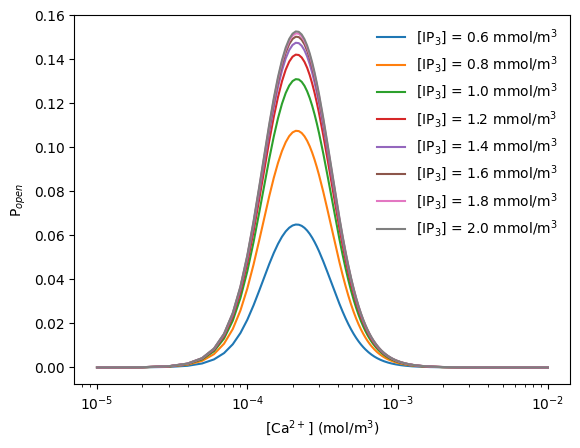

In [5]:
f, ax = plt.subplots()

for c_ip3, p_open in zip(c_ip3s, p_opens):
    ax.plot(c_cas, p_open, label=f'[IP$_3$] = {c_ip3*1e3} mmol/m$^3$')
ax.set_xscale('log')

ax.set_ylabel('P$_{open}$')
ax.set_xlabel('[Ca$^{2+}$] (mol/m$^3$)')
ax.legend(frameon=False)

## $P_{open}$ vs $[IP_3]$

In [6]:
c_ca = 0.0002
c_ip3s = np.arange(1e-4, 1e-2, 2e-8)
p_open = calc_p_open_ss(c_ca=c_ca,
                              c_ip3=c_ip3s,
                              x_act=4,
                              x_inact=4,
                              k_act=1.3e-4,
                              k_inact=3.5e-4,
                              a=4,
                              k_ip3=6.5e-4,
                              K=0.2)

Text(0.5, 0, '[IP$_3$] (mol/m$^3$)')

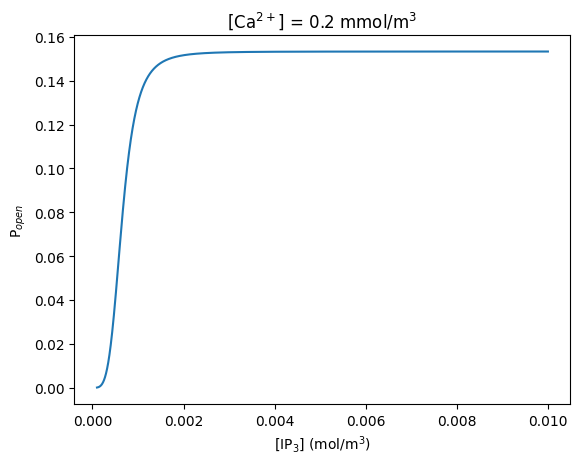

In [7]:
f, ax = plt.subplots()

ax.plot(c_ip3s, p_open)
ax.set_title('[Ca$^{2+}$]' + f' = {c_ca*1e3} mmol/m$^3$')

# ax.set_xscale('log')

ax.set_ylabel('P$_{open}$')
ax.set_xlabel('[IP$_3$] (mol/m$^3$)')

# Task 2

## Model

Model has many parameters. To keep them in order,
we can use namedtuple or dictionary. Here, we use
namedtuple

In [8]:
# Create a named tuple with its fields (attributes) —- our parameters -- listed in the second input argument
# Values are assigned to each parameter later in the code
params = namedtuple('params', 'ip3 a k_ip3 k_act x_inact k_inact k_ca r_ip3 r_leak r_serca p k_serca tau_inact K')

params.__doc__

'params(ip3, a, k_ip3, k_act, x_inact, k_inact, k_ca, r_ip3, r_leak, r_serca, p, k_serca, tau_inact, K)'

In [9]:
def model(t, state, model_parameters):

    """ Calcium dynamics model - Eqs. 2.9-2.13

    Parameters
    ----------

        - t : scalar
            Time point at which to evaluate
            dca/dt and df_inact/dt.

        - state : tuple with 2 elements
            Values of `ca` and `f_inact` at which to evaluate
            dca/dt and df_inact/dt.

        - model_parameters : collections.namedtuple
            Values of model parameters are attributes
            of `model_parameters`.

    Returns
    -------

        - tuple with 2 elements
            dca/dt and df_inact/dt

    """

    ca2, f_inact = state

    mp = model_parameters

    f_act_ss = ca2**mp.x_act / (ca2**mp.x_act + mp.k_act**mp.x_act)
    f_inact_ss = ca2**mp.x_inact / (ca2**mp.x_inact + mp.k_inact**mp.x_inact)

    p_open = f_act_ss * (1 - f_inact) * (mp.K * mp.ip3**mp.a) / (mp.ip3**mp.a + mp.k_ip3**mp.a)

    df_inactdt = (f_inact_ss - f_inact) / mp.tau_inact;

    dcadt = mp.k_ca * (mp.r_ip3 * p_open + mp.r_leak) - (mp.r_serca * ca2**mp.p) / (ca2**mp.p + mp.k_serca**mp.p)

    return (dcadt, df_inactdt)

## Parameters

In [10]:
# Param values from Table 2.1
params.ip3          = 1.5e-3
params.a            = 4.0
params.k_ip3        = 6.5e-4
params.x_act        = 4.0
params.k_act        = 1.3e-4
params.x_inact      = 4.0
params.k_inact      = 3.5e-4
params.k_ca         = 0.0526
params.r_ip3        = 7.5
params.r_leak       = 2.0
params.r_serca      = 0.170979
params.p            = 2.5
params.k_serca      = 0.7e-4
params.tau_inact    = 6.25
params.K            = 0.2

In [11]:
t_span = [0, 150]

dt = 0.01 # sec

t_start = 0 # Olga: We are only interested in the system's dyncamis in the steady state,
               # so we skip the initial part of the solution, where the system is far
               # from the steady state.
               # To see how the system evolves to the steady state, set t_start = 0


t_eval = np.arange(t_start, t_span[1], dt)

### Test run (Sec. 1.1.4 in the lecture notes; Fig. 1.1 of the lecture notes)

In [12]:
state_initial = (1e-4, 0.0)

In [13]:
solution = solve_ivp(model, t_span, state_initial, args=[params,], method='RK45', t_eval=t_eval, atol=1e-8)

/tmp/ipython-input-1153841257.py:39: RuntimeWarning: invalid value encountered in scalar power
  dcadt = mp.k_ca * (mp.r_ip3 * p_open + mp.r_leak) - (mp.r_serca * ca2**mp.p) / (ca2**mp.p + mp.k_serca**mp.p)


In [14]:
solution.y[0].min() * 1e-3

np.float64(9.700500956721768e-08)

Text(0, 0.5, '[Ca$^{2+}$]')

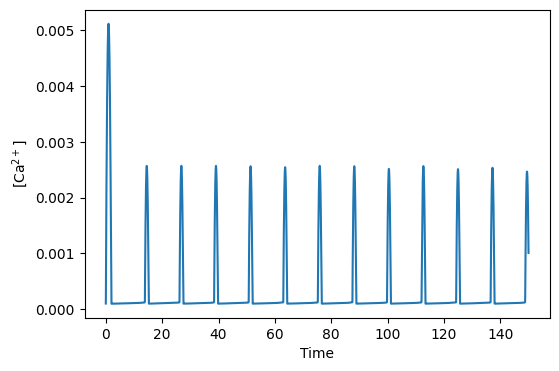

In [15]:
f, ax = plt.subplots(figsize=(6, 4))

ax.plot(solution.t, solution.y[0], '-')
ax.set_xlabel('Time')
ax.set_ylabel('[Ca$^{2+}$]')

### Amplitude of $[Ca^{2+}]$ spikes vs $[IP_3]$

In [16]:
ip3s = np.arange(1e-3, 1.5e-3, 1e-5)

In [17]:
ca_amp = np.zeros(ip3s.shape)

for i, ip3 in enumerate(ip3s):
    params.ip3 = ip3

    solution = solve_ivp(model, t_span, state_initial, args=[params,], t_eval=t_eval, method='RK23', atol=1e-8)

#     f, ax = plt.subplots(figsize=(6, 3))

#     ax.plot(solution.t, solution.y[0])
#     ax.set_xlabel('Time')
#     ax.set_ylabel('[Ca$^{2+}$]')
#     ax.set_title('[IP$_3$] = ' + f'{ip3} mmol/m3')

    ca_amp[i] = np.max(solution.y[0]) - np.min(solution.y[0])

/tmp/ipython-input-1153841257.py:39: RuntimeWarning: invalid value encountered in scalar power
  dcadt = mp.k_ca * (mp.r_ip3 * p_open + mp.r_leak) - (mp.r_serca * ca2**mp.p) / (ca2**mp.p + mp.k_serca**mp.p)


Text(0.5, 0, '[IP$_3$] (mmol/m3)')

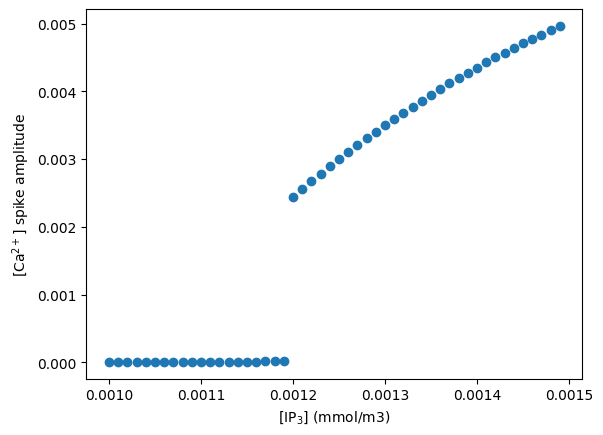

In [18]:
plt.figure()
plt.plot(ip3s, ca_amp, 'o')
plt.ylabel('[Ca$^{2+}$] spike amplitude')
plt.xlabel('[IP$_3$] (mmol/m3)')

# Task 3: How 'very high' IP3 concentration influences amplitude of Ca spikes?

In [19]:
from scipy.signal import find_peaks

### Amplitude of $[Ca^{2+}]$ spikes vs $[IP_3]$

In [20]:
ip3s = np.arange(1e-3, 10e-3, 5e-4)

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-1153841257.py:39: RuntimeWarning: invalid value encountered in scalar power
  dcadt = mp.k_ca * (mp.r_ip3 * p_open + mp.r_leak) - (mp.r_serca * ca2**mp.p) / (ca2**mp.p + mp.k_serca**mp.p)


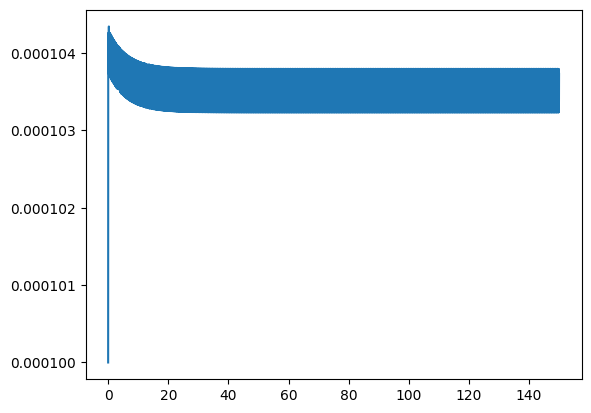

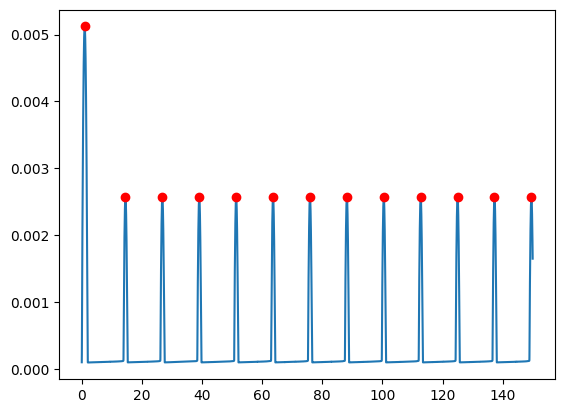

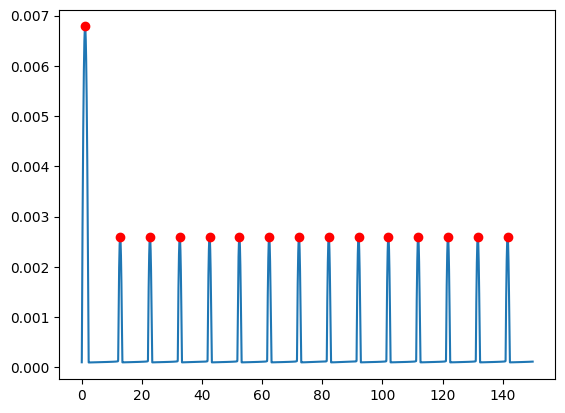

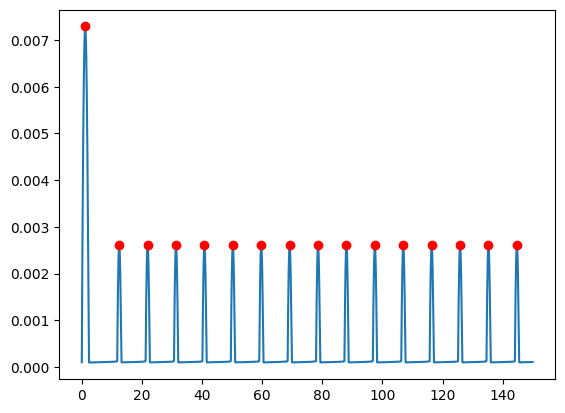

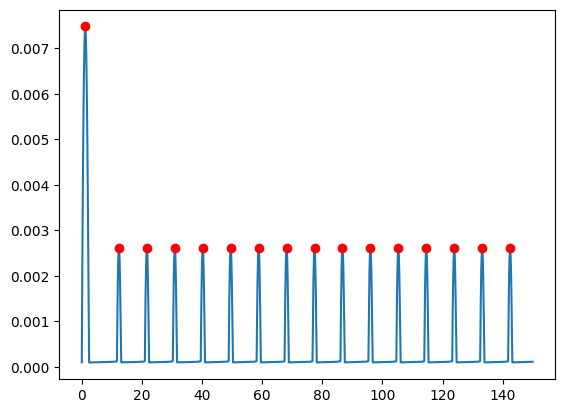

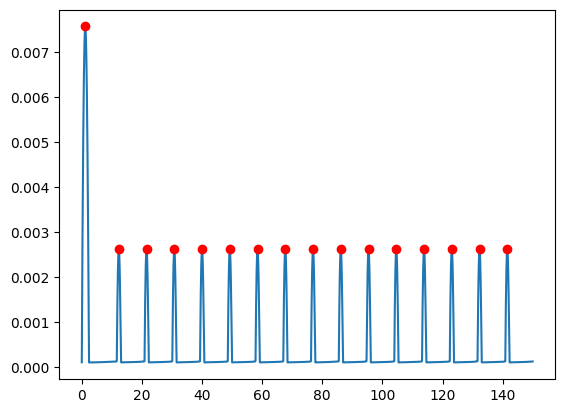

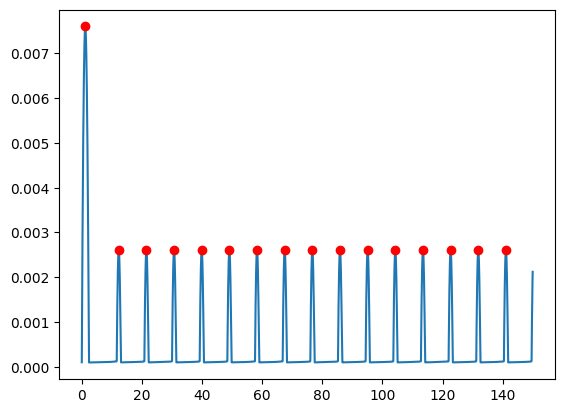

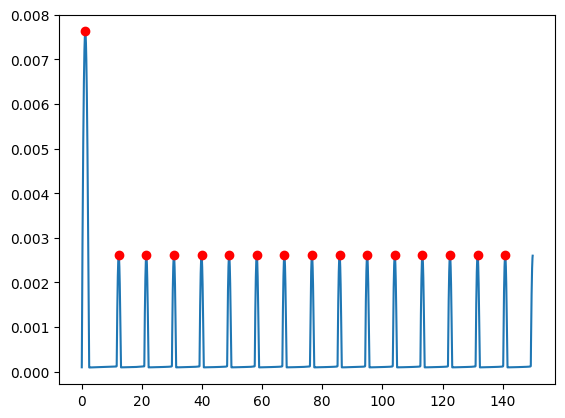

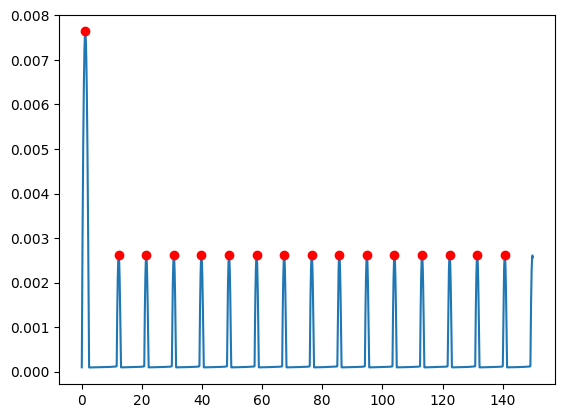

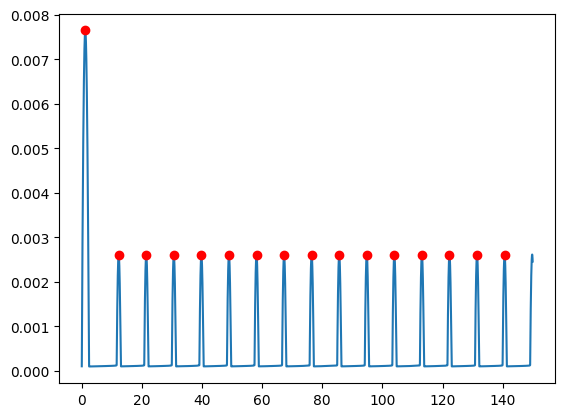

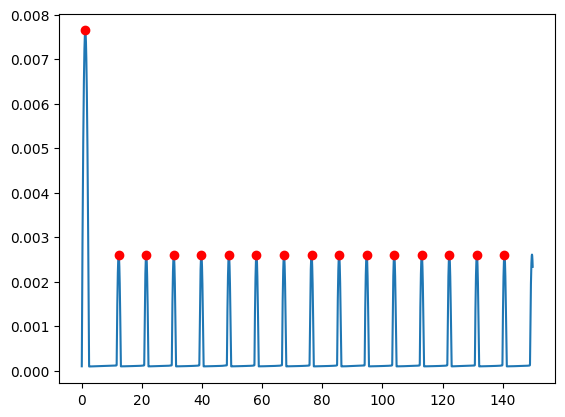

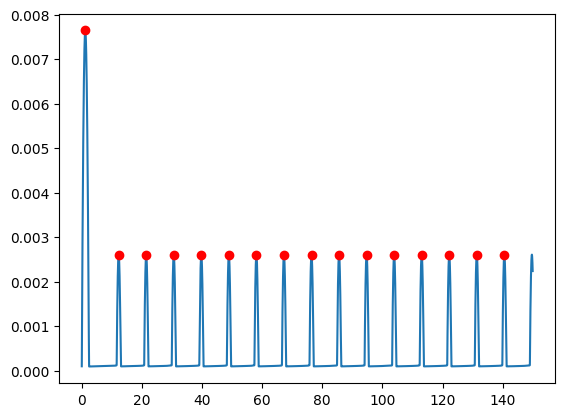

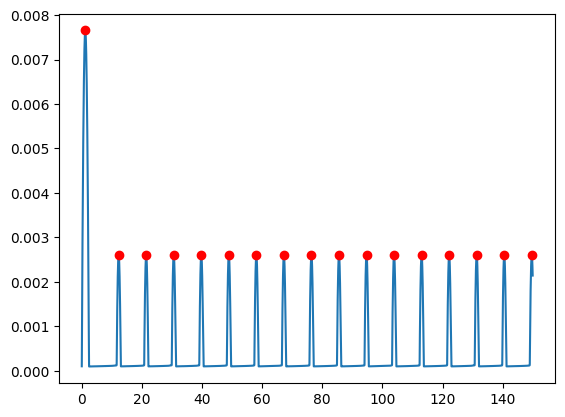

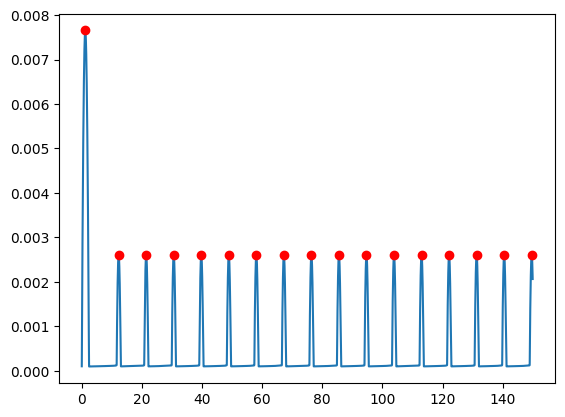

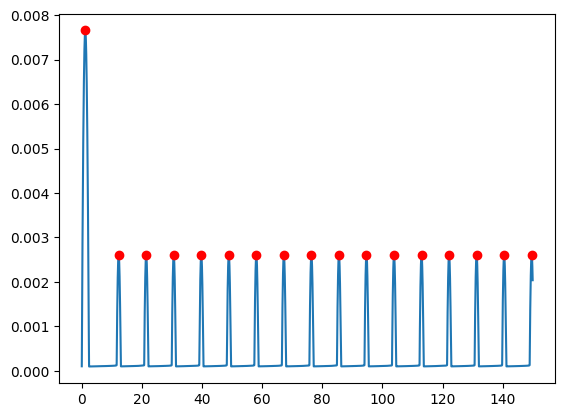

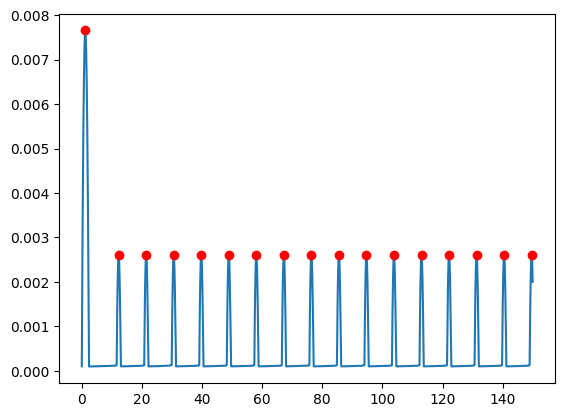

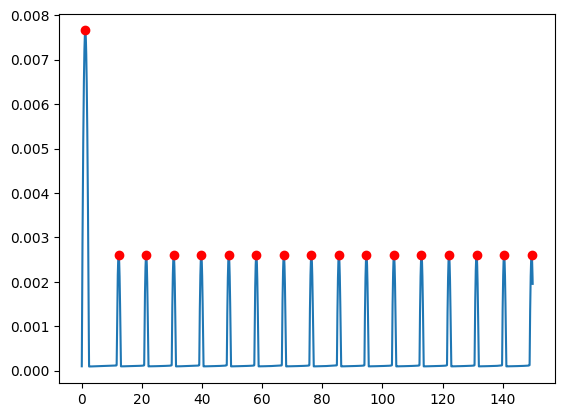

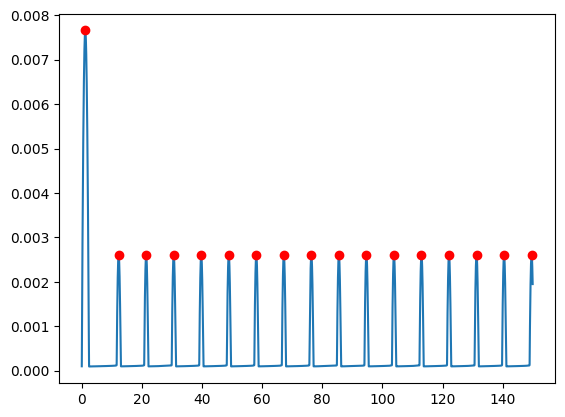

In [21]:
ca_amp = np.zeros(ip3s.shape)
ca_period = np.zeros(ip3s.shape)

for i, ip3 in enumerate(ip3s):
    params.ip3 = ip3

    solution = solve_ivp(model, t_span, state_initial, args=[params,], t_eval=t_eval, method='RK23', atol=1e-8)

    pks, props = find_peaks(solution.y[0], prominence=solution.y[0].mean())
    peak_times = solution.t[pks]
    plt.figure()
    plt.plot(solution.t, solution.y[0])
    plt.plot(peak_times, solution.y[0][pks], 'ro')

    ca_amp[i] = np.max(solution.y[0]) - np.min(solution.y[0])
    ca_period[i] = np.mean(np.diff(peak_times))


Text(0.5, 0, '[IP$_3$] (mmol/m3)')

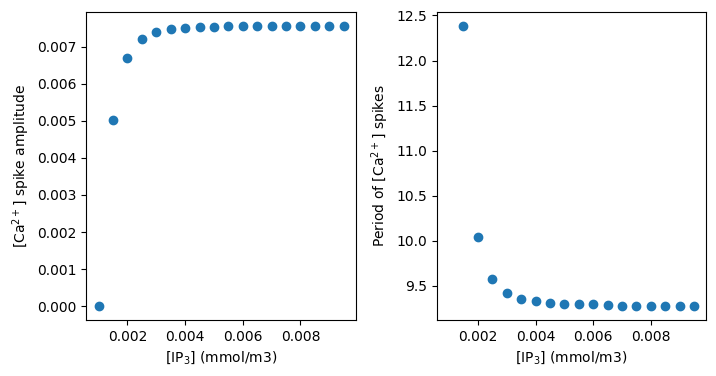

In [22]:
f, (ax, ax1) = plt.subplots(1,2, figsize=(8,4), sharex=True)

plt.subplots_adjust(wspace=0.3)

ax.plot(ip3s, ca_amp, 'o')
ax.set_ylabel('[Ca$^{2+}$] spike amplitude')
ax.set_xlabel('[IP$_3$] (mmol/m3)')

ax1.plot(ip3s, ca_period, 'o')
ax1.set_ylabel('Period of [Ca$^{2+}$] spikes')
ax1.set_xlabel('[IP$_3$] (mmol/m3)')

# Task 4: How tau_inactivation influences amplitude of Ca spikes?

In [23]:
taus = np.arange(5, 10.1, 0.5)
params.ip3 = 1.5e-3

/tmp/ipython-input-1153841257.py:39: RuntimeWarning: invalid value encountered in scalar power
  dcadt = mp.k_ca * (mp.r_ip3 * p_open + mp.r_leak) - (mp.r_serca * ca2**mp.p) / (ca2**mp.p + mp.k_serca**mp.p)


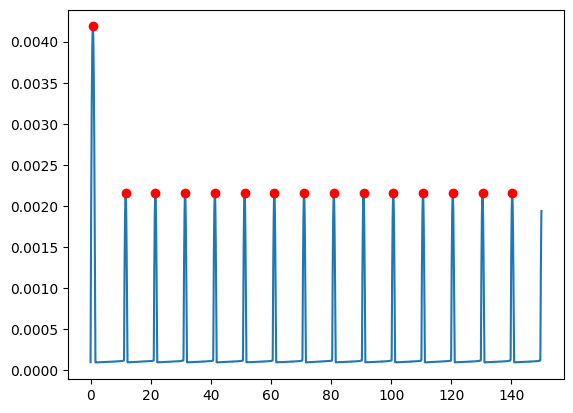

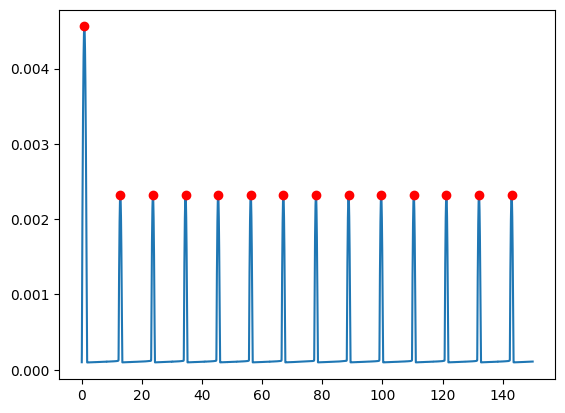

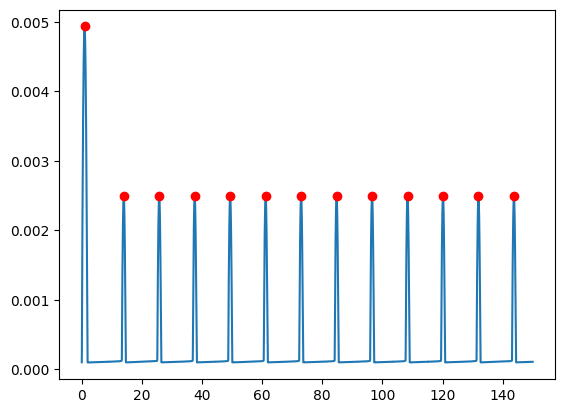

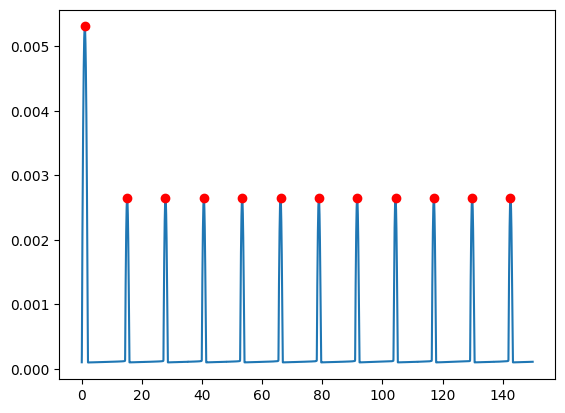

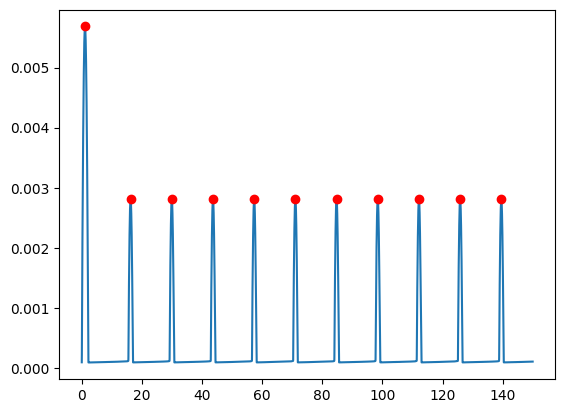

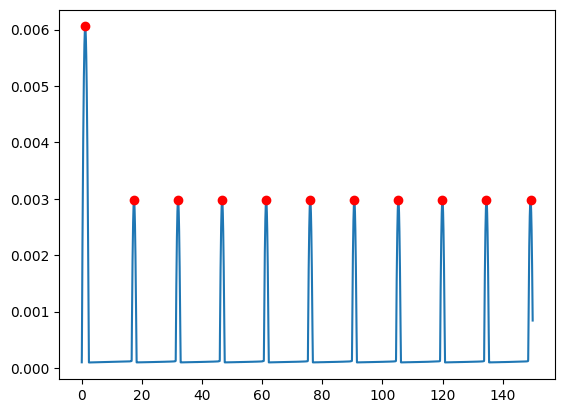

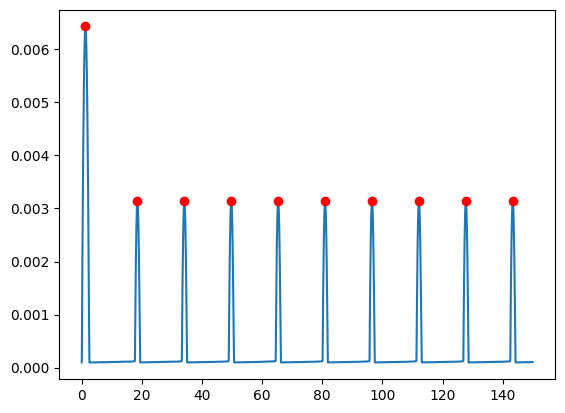

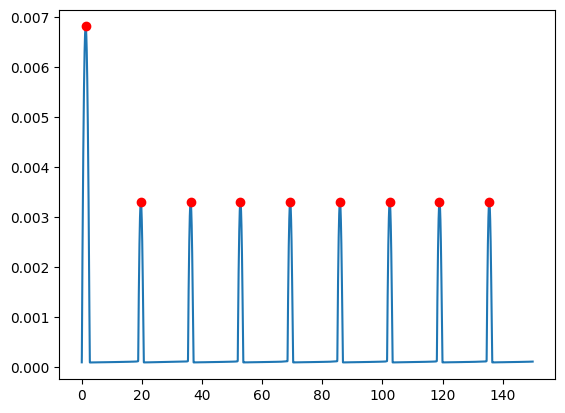

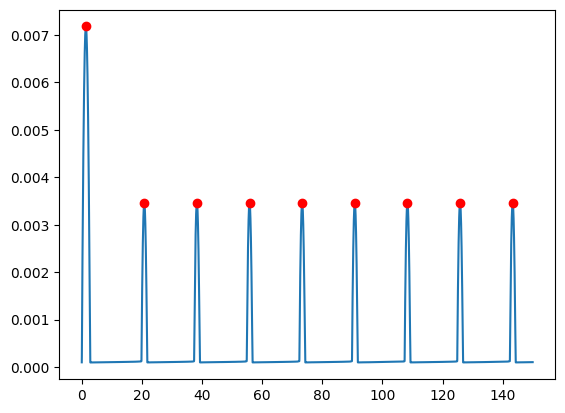

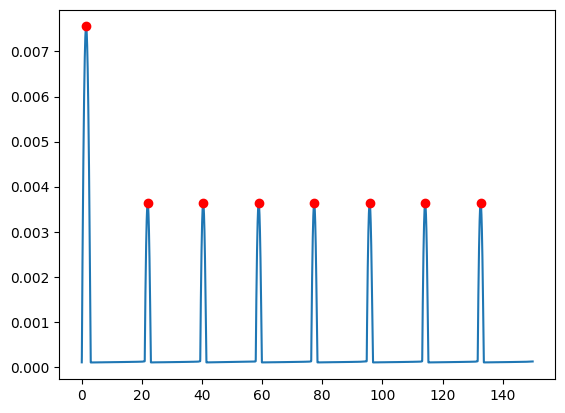

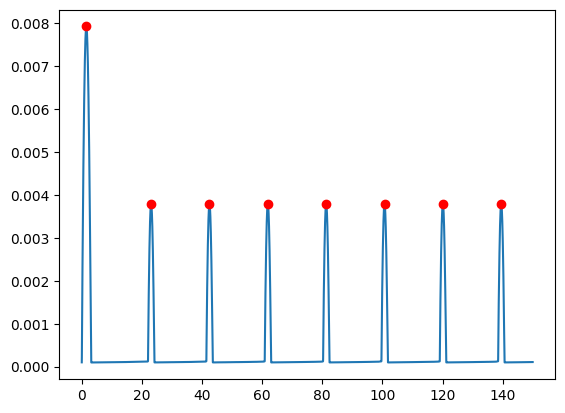

In [24]:
ca_amp = np.zeros(taus.shape)
ca_period = np.zeros(taus.shape)

for i, tau in enumerate(taus):
    params.tau_inact = tau

    solution = solve_ivp(model, t_span, state_initial, args=[params,], t_eval=t_eval, method='RK23', atol=1e-12)

    pks, props = find_peaks(solution.y[0], prominence=solution.y[0].mean())
    peak_times = solution.t[pks]
    plt.figure()
    plt.plot(solution.t, solution.y[0])
    plt.plot(peak_times, solution.y[0][pks], 'ro')

    ca_amp[i] = np.max(solution.y[0]) - np.min(solution.y[0])
    ca_period[i] = np.mean(np.diff(peak_times))


Text(0.5, 0, '$\tau_{inact}$')

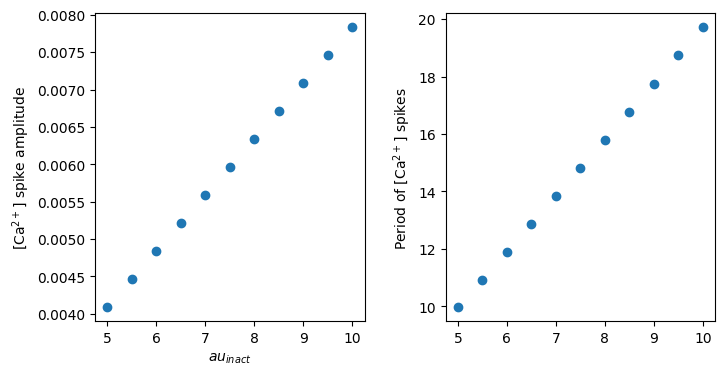

In [25]:
f, (ax, ax1) = plt.subplots(1,2, figsize=(8,4),sharex=True)

plt.subplots_adjust(wspace=0.3)

ax.plot(taus, ca_amp, 'o')
ax.set_ylabel('[Ca$^{2+}$] spike amplitude')
ax.set_xlabel('$\tau_{inact}$')

ax1.plot(taus, ca_period, 'o')
ax1.set_ylabel('Period of [Ca$^{2+}$] spikes')
ax.set_xlabel('$\tau_{inact}$')